In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
import numpy as np
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

C:\Users\musae\Desktop\files\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Загрузка данных

In [4]:
ds = load_dataset('uoft-cs/cifar10')
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [5]:
ds["train"].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [6]:
sample = ds["train"][0]
print(type(sample))
print(sample)

<class 'dict'>
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x237FC9B7090>, 'label': 0}


In [7]:
class CifarDataset(Dataset):
    def __init__(self, data, transforms):
        self.data = data
        self.transforms = transforms
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]

        image = item['img']
        label = item['label']

        if self.transforms:
            image = self.transforms(image)
        return image, label

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
cifar10_train = CifarDataset(ds['train'], transforms=transform_train)

g = torch.Generator()
g.manual_seed(seed)

cifar10_loader_train = DataLoader(
    cifar10_train,
    batch_size=32,
    shuffle=True,
    generator=g
)

In [10]:
cifar10_test = CifarDataset(ds['test'], transforms=transform_test)

cifar10_loader_test = DataLoader(
    cifar10_test, 
    batch_size=128, 
    shuffle=False
)

# Создание модели

In [11]:
class GaussianActivationNoise(nn.Module):
    def __init__(self, sigma, relative):
        super().__init__()
        self.sigma = sigma
        self.relative = relative
    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x
        
        noise = torch.randn_like(x)

        if self.relative:
            scale = x.detach().std()
            return x + self.sigma * scale * noise
        else:
            return x + self.sigma * noise

In [12]:
class Net(nn.Module):
    def __init__(self, sigma1=0, sigma2=0, sigma3=0, relative=True):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 256),
            nn.ReLU(),
            GaussianActivationNoise(sigma3, relative),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)

        return x

# Шум параметров

In [13]:
def get_omega_for_parameter(name, omega1, omega2, omega3):
    if name.startswith('block1'):
        return omega1
    elif name.startswith('block2'):
        return omega2
    else:
        return omega3

# Обучение

In [14]:
num_epochs = 20
lr = 1e-2

In [15]:
criterion = nn.CrossEntropyLoss()

In [16]:
def evaluate(model, val_loader, final=False):
    model.eval()

    correct = 0
    running_loss = 0.0
    
    correct_pred = {i: 0 for i in range(10)}
    total_pred = {i: 0 for i in range(10)}

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += pred.eq(target.data).sum()

            for label, prediction in zip(target, pred):
                label = label.item()
                prediction = prediction.item()
                if label == prediction:
                    correct_pred[label] += 1
    
                total_pred[label] += 1
                

    accuracy = correct / len(val_loader.dataset)
    avg_loss = running_loss / len(val_loader)

    if final:
        for i in range(10):
            acc = 100 * correct_pred[i] / total_pred[i]
            print(f"Accuracy class {i} = {acc:.1f} %")
        

    return accuracy.cpu().item(), avg_loss

In [17]:
def train(net, num_epochs, omega1, omega2, omega3, relative_params=True):
    losses = []
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(cifar10_loader_train):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
    
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                for name, param in net.named_parameters():
                    if param.requires_grad:
                        omega = get_omega_for_parameter(name, omega1, omega2, omega3)
                        if omega > 0:
                            noise = torch.randn_like(param)

                            if relative_params:
                                scale = param.detach().std()
                                param.add_(omega * scale * noise)
                            else:
                                param.add_(omega * noise)
                
            running_loss += loss.item()
        if epoch == num_epochs-1: 
            val_acc, val_loss = evaluate(net, cifar10_loader_test, True)
        else:
            val_acc, val_loss = evaluate(net, cifar10_loader_test)
        losses.append(running_loss/len(cifar10_loader_train))
        print(f'epoch: {epoch+1}, train loss: {running_loss/len(cifar10_loader_train)}, val_acc: {val_acc}, val_loss: {val_loss}')

        plt.plot(losses)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss");

epoch: 1, train loss: 1.5086867653705796, val_acc: 0.5870999693870544, val_loss: 1.2076450729671913
epoch: 2, train loss: 1.0343385256030815, val_acc: 0.7067999839782715, val_loss: 0.8184528290470944
epoch: 3, train loss: 0.857042787399951, val_acc: 0.7355999946594238, val_loss: 0.7481525231011307
epoch: 4, train loss: 0.7687168308960957, val_acc: 0.7529999613761902, val_loss: 0.7077612488330165
epoch: 5, train loss: 0.7048848246486997, val_acc: 0.7746999859809875, val_loss: 0.6524323217476471
epoch: 6, train loss: 0.6638849073793365, val_acc: 0.7798999547958374, val_loss: 0.6404250573508347
epoch: 7, train loss: 0.6237945399430037, val_acc: 0.7786999940872192, val_loss: 0.6565092934083335
epoch: 8, train loss: 0.5941832158154429, val_acc: 0.7870999574661255, val_loss: 0.6348760818378835
epoch: 9, train loss: 0.5671317590518556, val_acc: 0.8112999796867371, val_loss: 0.5622296223912058
epoch: 10, train loss: 0.546045042407566, val_acc: 0.8161999583244324, val_loss: 0.542359759158726
ep

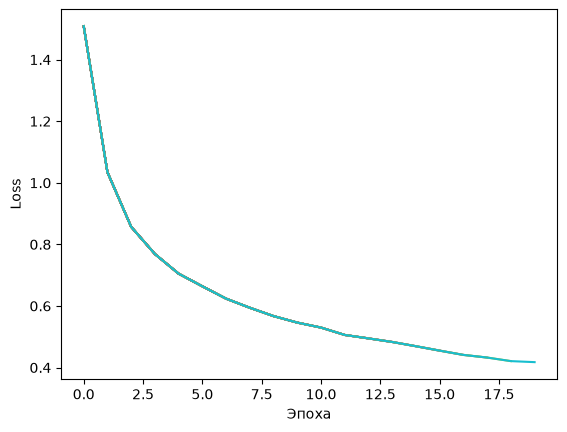

In [18]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.482780113673256, val_acc: 0.6143999695777893, val_loss: 1.0742662269857866
epoch: 2, train loss: 1.0125024144419172, val_acc: 0.6936999559402466, val_loss: 0.8507785223707368
epoch: 3, train loss: 0.846225412415909, val_acc: 0.7382999658584595, val_loss: 0.7616804596744006
epoch: 4, train loss: 0.7612514280102151, val_acc: 0.7638999819755554, val_loss: 0.6962286471566067
epoch: 5, train loss: 0.6948669711634354, val_acc: 0.7881999611854553, val_loss: 0.6187385826171199
epoch: 6, train loss: 0.654183615506725, val_acc: 0.7870999574661255, val_loss: 0.6127406660514542
epoch: 7, train loss: 0.6189657876164351, val_acc: 0.7971999645233154, val_loss: 0.6001004033450839
epoch: 8, train loss: 0.5902161372066383, val_acc: 0.8036999702453613, val_loss: 0.5847979187965393
epoch: 9, train loss: 0.5645641734679387, val_acc: 0.8093999624252319, val_loss: 0.5590425767476046
epoch: 10, train loss: 0.5426407433326474, val_acc: 0.8172999620437622, val_loss: 0.5326692963702769
ep

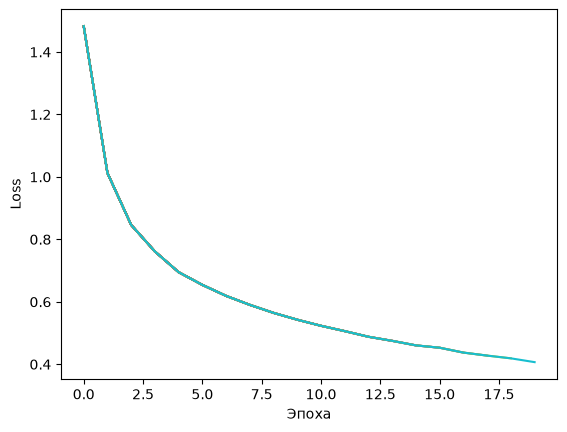

In [19]:
start = time.time()

net = Net(0, 0, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.5158341342031536, val_acc: 0.5927000045776367, val_loss: 1.1177711290649222
epoch: 2, train loss: 1.0545241456915, val_acc: 0.6773999929428101, val_loss: 0.9080078179323221
epoch: 3, train loss: 0.8727627044218287, val_acc: 0.733199954032898, val_loss: 0.7753519823279562
epoch: 4, train loss: 0.775055558175821, val_acc: 0.7483999729156494, val_loss: 0.7202534690687928
epoch: 5, train loss: 0.7070644576619698, val_acc: 0.7768999934196472, val_loss: 0.6388069911848141
epoch: 6, train loss: 0.6653582768244234, val_acc: 0.7852999567985535, val_loss: 0.6374620708483684
epoch: 7, train loss: 0.6292631051914859, val_acc: 0.8025999665260315, val_loss: 0.580470543873461
epoch: 8, train loss: 0.5983485886475556, val_acc: 0.7947999835014343, val_loss: 0.6074403222603134
epoch: 9, train loss: 0.5737372365466159, val_acc: 0.8024999499320984, val_loss: 0.5699956635885601
epoch: 10, train loss: 0.5532658158283698, val_acc: 0.8079999685287476, val_loss: 0.5697034559672391
epoch

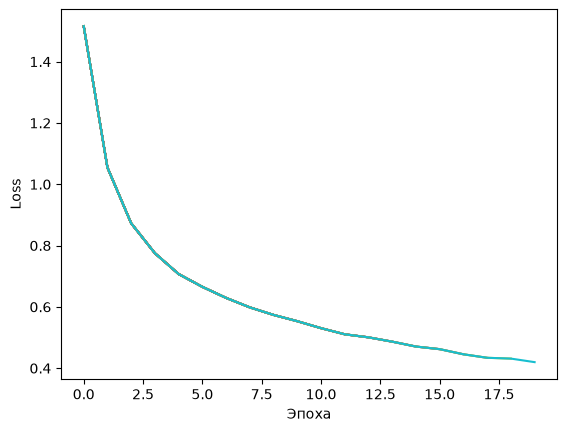

In [20]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 1e-3)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.5547490748395083, val_acc: 0.568399965763092, val_loss: 1.2155047511752648
epoch: 2, train loss: 1.0557273314003752, val_acc: 0.685699999332428, val_loss: 0.9130522533308102
epoch: 3, train loss: 0.8626311552959303, val_acc: 0.7294999957084656, val_loss: 0.7725604417957838
epoch: 4, train loss: 0.7736346330767783, val_acc: 0.7513999938964844, val_loss: 0.7470411892178692
epoch: 5, train loss: 0.719187777992326, val_acc: 0.7784000039100647, val_loss: 0.6439792634565619
epoch: 6, train loss: 0.6725172097112456, val_acc: 0.7879999876022339, val_loss: 0.6023486724382714
epoch: 7, train loss: 0.6356018450747525, val_acc: 0.8000999689102173, val_loss: 0.5985897074017343
epoch: 8, train loss: 0.605474458298314, val_acc: 0.8001999855041504, val_loss: 0.5834652611726447
epoch: 9, train loss: 0.5803491160302153, val_acc: 0.8050000071525574, val_loss: 0.5703381302801869
epoch: 10, train loss: 0.5564661119526498, val_acc: 0.8175999522209167, val_loss: 0.531114143095439
epoc

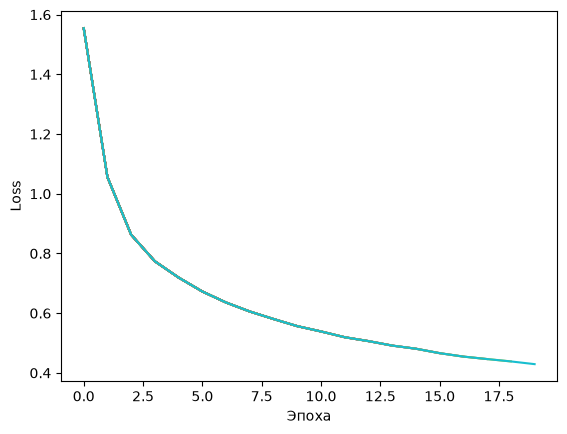

In [21]:
start = time.time()

net = Net(0.03, 0.03, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 1e-4, 1e-4, 1e-4)

print('Время обучения', time.time() - start)